In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD

import lightning as L
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
class BasicLightning(L.LightningModule):
    
    def __init__(self):
        
        super().__init__()
        
        self.w00 = nn.Parameter(torch.tensor(1.70), requires_grad=False)
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad=False)
        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad=False)

        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad=False)
        self.b10 = nn.Parameter(torch.tensor(0.00), requires_grad=False)
        self.w11 = nn.Parameter(torch.tensor(2.70), requires_grad=False)

        self.final_bias = nn.Parameter(torch.tensor(-16.0), requires_grad=False)

    def forward(self, input):
        
        input_to_top_relu = (input*self.w00) + self.b00
        top_relu_output = F.relu(input_to_top_relu)
        scaled_top_relu_output = top_relu_output*self.w01

        input_to_bottom_relu = (input*self.w10) + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output*self.w11

        input_to_final_relu = (scaled_top_relu_output + scaled_bottom_relu_output) + self.final_bias

        output = F.relu(input_to_final_relu)

        return output
    

In [3]:
input_doses = torch.linspace(start=0, end=1, steps=11)
input_doses

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000])

In [4]:
model = BasicLightning()
output_values = model(input_doses)

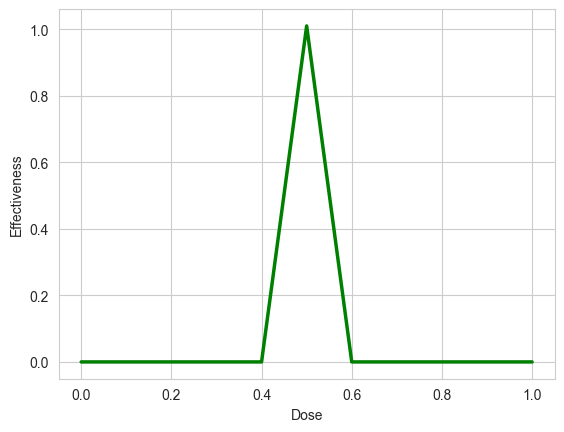

In [5]:
sns.set_style(style="whitegrid")
sns.lineplot(
    x=input_doses,
    y=output_values,
    color="green",
    linewidth=2.5
)
plt.ylabel("Effectiveness")
plt.xlabel("Dose")
plt.show()

In [6]:
class BasicLightning_Train(BasicLightning):
    
    def __init__(self):
        super().__init__()
        self.final_bias = nn.Parameter(torch.tensor(0.0), requires_grad=True)
        self.learning_rate = 0.01
    
    def configure_optimizers(self):
        return SGD(self.parameters(), lr=self.learning_rate)
    
    def training_step(self, batch, batch_idx):
        input_i, label_i = batch
        output_i = self.forward(input_i)
        loss = (output_i - label_i)**2
        return loss


In [7]:
model2 = BasicLightning_Train()
output_values2 = model2(input_doses)

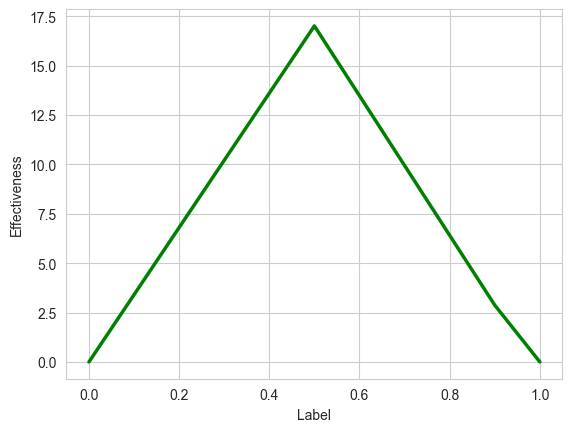

In [8]:
sns.set_style(style="whitegrid")
sns.lineplot(
    x=input_doses,
    y=output_values2.detach(),
    color="green",
    linewidth=2.5
)
plt.ylabel("Effectiveness")
plt.xlabel("Label")
plt.show()

In [9]:
inputs = torch.tensor([0, 0.5, 1]*100)
labels = torch.tensor([0.0, 1.0, 0.0]*100)

dataset = TensorDataset(inputs, labels)
dataloader = DataLoader(dataset)

In [10]:
trainer = L.Trainer(max_epochs=24)
tuner = L.pytorch.tuner.Tuner(trainer)
lr_find_results = tuner.lr_find(
    model2,
    train_dataloaders=dataloader,
    min_lr=0.001,
    max_lr=1.0,
    early_stop_threshold=None
)
new_lr = lr_find_results.suggestion()
print(f"lr_find() {new_lr:0.5f} for learning rate") 

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performanc

lr_find() 0.00214 for learning rate


In [11]:
model2.learning_rate = new_lr

trainer.fit(model2, train_dataloaders=dataloader)

print(model2.final_bias.data)


  | Name         | Type | Params | Mode
---------------------------------------------
  | other params | n/a  | 7      | n/a 
---------------------------------------------
1         Trainable params
6         Non-trainable params
7         Total params
0.000     Total estimated model params size (MB)
0         Modules in train mode
0         Modules in eval mode


Epoch 23: 100%|██████████| 300/300 [00:00<00:00, 663.51it/s, v_num=3]

`Trainer.fit` stopped: `max_epochs=24` reached.


Epoch 23: 100%|██████████| 300/300 [00:00<00:00, 658.66it/s, v_num=3]
tensor(-16.0094)
